R² Score: 0.4883
CV R² Mean: -0.4618 ± 0.9985
MAE: ₹20,492,810


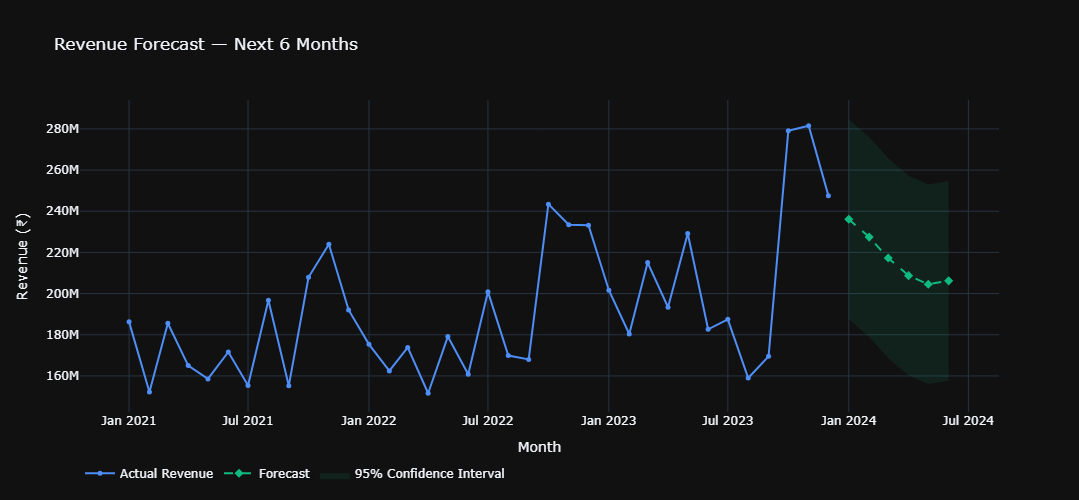

✅ Forecast complete!
    Forecast     Lower CI     Upper CI
₹236,136,803 ₹187,631,196 ₹284,642,411
₹227,439,983 ₹178,934,376 ₹275,945,591
₹217,257,226 ₹168,751,618 ₹265,762,833
₹208,721,299 ₹160,215,691 ₹257,226,906
₹204,523,704 ₹156,018,097 ₹253,029,312
₹206,193,491 ₹157,687,884 ₹254,699,098


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

df = pd.read_csv('../data/processed/sales_clean.csv', parse_dates=['date'])

# ── Build monthly time-series ─────────────────────────────
monthly = (
    df.groupby(pd.Grouper(key='date', freq='MS'))['revenue']
    .sum()
    .reset_index()
    .rename(columns={'date': 'month', 'revenue': 'revenue'})
)

# Feature engineering
monthly['time_index'] = np.arange(len(monthly))
monthly['month_num']   = monthly['month'].dt.month
monthly['sin_season'] = np.sin(2 * np.pi * monthly['month_num'] / 12)
monthly['cos_season'] = np.cos(2 * np.pi * monthly['month_num'] / 12)

X = monthly[['time_index', 'sin_season', 'cos_season']]
y = monthly['revenue']

# Train model
model = LinearRegression()
model.fit(X, y)

cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"R² Score: {model.score(X, y):.4f}")
print(f"CV R² Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"MAE: ₹{mean_absolute_error(y, model.predict(X)):,.0f}")

# ── Forecast next 6 months ────────────────────────────────
last_idx = monthly['time_index'].max()
last_date = monthly['month'].max()

future_months = pd.date_range(last_date + pd.DateOffset(months=1), periods=6, freq='MS')
future_idx = np.arange(last_idx + 1, last_idx + 7)
future_m   = future_months.month

X_future = pd.DataFrame({
    'time_index': future_idx,
    'sin_season': np.sin(2 * np.pi * future_m / 12),
    'cos_season': np.cos(2 * np.pi * future_m / 12),
})
forecast   = model.predict(X_future)
residuals  = y - model.predict(X)
std_err    = residuals.std()
ci_upper   = forecast + 1.96 * std_err
ci_lower   = forecast - 1.96 * std_err

# ── Plotly Visualization ──────────────────────────────────
fig = go.Figure()

# Actual revenue
fig.add_trace(go.Scatter(
    x=monthly['month'], y=monthly['revenue'],
    mode='lines+markers', name='Actual Revenue',
    line=dict(color='#4f8ef7', width=2),
    marker=dict(size=5)
))

# Forecast
fig.add_trace(go.Scatter(
    x=future_months, y=forecast,
    mode='lines+markers', name='Forecast',
    line=dict(color='#10b981', width=2, dash='dash'),
    marker=dict(size=7, symbol='diamond')
))

# Confidence interval
fig.add_trace(go.Scatter(
    x=list(future_months) + list(future_months[::-1]),
    y=list(ci_upper) + list(ci_lower[::-1]),
    fill='toself', fillcolor='rgba(16,185,129,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    name='95% Confidence Interval'
))

fig.update_layout(
    title='Revenue Forecast — Next 6 Months',
    xaxis_title='Month', yaxis_title='Revenue (₹)',
    template='plotly_dark', height=500,
    hovermode='x unified',
    legend=dict(orientation='h', y=-0.15)
)

fig.write_html('../data/exports/forecast_chart.html')
fig.show()
print("✅ Forecast complete!")

# Print forecast table
forecast_df = pd.DataFrame({
    'Forecast': [f"₹{v:,.0f}" for v in forecast],
    'Lower CI': [f"₹{v:,.0f}" for v in ci_lower],
    'Upper CI': [f"₹{v:,.0f}" for v in ci_upper],
})
print(forecast_df.to_string(index=False))